In [2]:
# imports, file paths, MODEL_CONFIGS, cuda

import os
import sys
import math
import torch
import random
import numpy as np
import torch.nn as nn
from pathlib import Path
import torch.nn.functional as F
import matplotlib.pyplot as plt
from einops import rearrange, reduce, repeat, einsum


import training_engine as training_engine 
import inference_engine as inference_engine
from rms_norm import RMSNorm


MODEL_CONFIGS = {
    "embed_dim"   : 2**5,   # 32
    "max_seq_len" : 2**6,   # 64
    "vocab_size"  : 2**11,  # 2048
    "num_attn_heads": 2**2, # 4
    
    "batch_size"  : 2**4,   # 16
    "learning_rate" : 1e-3,

    "save_path" : "../models/level4.2_rotary_positional_encoding.pt",
    "loss_history" : "../models/level4.2_rotary_positional_encoding_loss_history.txt",

}



# Device configuration
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(device)




cuda


In [3]:
class Level4_2_RoPE_Model(nn.Module):

    def __init__(self):
        super().__init__()
        self.embed_dim     = MODEL_CONFIGS["embed_dim"]
        self.vocab_size    = MODEL_CONFIGS["vocab_size"]
        self.max_seq_len   = MODEL_CONFIGS["max_seq_len"]
        self.num_attn_heads = MODEL_CONFIGS["num_attn_heads"]

        self.embed   = nn.Parameter(torch.randn(self.vocab_size, self.embed_dim) * 0.02)
        self.unembed = nn.Parameter(torch.randn(self.embed_dim, self.vocab_size) * 0.02)

        self.rms_norm_1 = RMSNorm(self.embed_dim)
        self.rms_norm_2 = RMSNorm(self.embed_dim)

        # RoPE-aware multi-head attention
        self.multi_attn = MultiHeadCausalAttentionRoPE(
            max_seq_len=self.max_seq_len
        )

    def forward(self, idx: torch.Tensor) -> torch.Tensor:

        x = self.embed[idx]                          # (batch, sqq_len, embed_dim)

        x = x + self.multi_attn(self.rms_norm_1(x))  # residual

        logits = einsum(
            self.rms_norm_2(x), self.unembed,
            "batch seq_len embed_dim, embed_dim vocab_size -> batch seq_len vocab_size"
        )
        return logits


In [4]:
class MultiHeadCausalAttentionRoPE(nn.Module):
    def __init__(self, max_seq_len: int):
        super().__init__()
        self.num_heads = MODEL_CONFIGS["num_attn_heads"]
        self.embed_dim = MODEL_CONFIGS["embed_dim"]
        assert self.embed_dim % self.num_heads == 0

        self.head_dim = self.embed_dim // self.num_heads

        self.query_proj = nn.Parameter(torch.randn(self.embed_dim, self.embed_dim) * 0.02)
        self.key_proj   = nn.Parameter(torch.randn(self.embed_dim, self.embed_dim) * 0.02)
        self.value_proj = nn.Parameter(torch.randn(self.embed_dim, self.embed_dim) * 0.02)
        self.out_proj   = nn.Parameter(torch.randn(self.embed_dim, self.embed_dim) * 0.02)


        # Precompute RoPE frequencies
        self.register_buffer(
            "freqs_cis",
            precompute_freqs_cis(self.head_dim, max_seq_len),
            persistent=False,
        )


    def forward(self, x):
        b, s, _ = x.shape

        q = einsum(x, self.query_proj, "b s d, d d_out -> b s d_out")
        k = einsum(x, self.key_proj,   "b s d, d d_out -> b s d_out")
        v = einsum(x, self.value_proj, "b s d, d d_out -> b s d_out")

        # Split heads
        q = rearrange(q, "b s (h d) -> b h s d", h=self.num_heads)
        k = rearrange(k, "b s (h d) -> b h s d", h=self.num_heads)
        v = rearrange(v, "b s (h d) -> b h s d", h=self.num_heads)
        
        # ===== RoPE applied here =====
        q, k = apply_rotary_emb(q, k, self.freqs_cis[:s])

        # Scaled dot-product attention
        scale = self.head_dim ** -0.5
        attn_scores = einsum(q, k, "b h q d, b h k d -> b h q k") * scale

        causal_mask = torch.triu(
            torch.ones(s, s, device=x.device, dtype=torch.bool), diagonal=1
        )
        attn_scores = attn_scores.masked_fill(causal_mask, float("-inf"))
        attn_weights = torch.softmax(attn_scores, dim=-1)

        out = einsum(attn_weights, v, "b h q k, b h k d -> b h q d")
        out = rearrange(out, "b h s d -> b s (h d)")

        return einsum(out, self.out_proj, "b s d, d d_out -> b s d_out")

In [5]:
def precompute_freqs_cis(dim: int, end: int, theta: float = 10000.0):
    """
    Precompute complex frequencies for RoPE.
    Returns: (end, dim//2) complex tensor
    """
    freqs = 1.0 / (theta ** (torch.arange(0, dim, 2)[: dim // 2].float() / dim))
    t = torch.arange(end, device=freqs.device)
    freqs = torch.outer(t, freqs)                  # (seq, dim//2)
    freqs_cis = torch.polar(torch.ones_like(freqs), freqs)  # complex
    return freqs_cis


def apply_rotary_emb(
    xq: torch.Tensor,       # (batch, heads, seq, head_dim)
    xk: torch.Tensor,
    freqs_cis: torch.Tensor # (seq, head_dim//2)
):
    """Apply RoPE to queries and keys."""
    # → complex view: (..., head_dim//2)
    xq_ = torch.view_as_complex(xq.float().reshape(*xq.shape[:-1], -1, 2))
    xk_ = torch.view_as_complex(xk.float().reshape(*xk.shape[:-1], -1, 2))

    # Broadcast frequencies
    freqs_cis = rearrange(freqs_cis, "s d -> 1 1 s d")

    # Rotate
    xq_out = torch.view_as_real(xq_ * freqs_cis).flatten(3)
    xk_out = torch.view_as_real(xk_ * freqs_cis).flatten(3)

    return xq_out.type_as(xq), xk_out.type_as(xk)

Step 0000 | Batch Loss: 7.6305 nats
Step 0005 | Batch Loss: 7.6246 nats
Step 0010 | Batch Loss: 7.6026 nats
Step 0015 | Batch Loss: 7.5819 nats
Step 0020 | Batch Loss: 7.5255 nats
Step 0025 | Batch Loss: 7.4845 nats
Step 0030 | Batch Loss: 7.4258 nats
Step 0035 | Batch Loss: 7.3797 nats
Step 0040 | Batch Loss: 7.3060 nats
Step 0045 | Batch Loss: 7.2553 nats
Step 0050 | Batch Loss: 7.1908 nats
Step 0055 | Batch Loss: 7.1500 nats
Step 0060 | Batch Loss: 7.1278 nats
Step 0065 | Batch Loss: 7.1565 nats
Step 0070 | Batch Loss: 7.1089 nats
Step 0075 | Batch Loss: 7.0624 nats
Step 0080 | Batch Loss: 7.0150 nats
Step 0085 | Batch Loss: 6.9865 nats
Step 0090 | Batch Loss: 7.0257 nats
Step 0095 | Batch Loss: 6.9853 nats
Step 0099 | Batch Loss: 6.9842 nats

Saving model weights to: ../models/level4.2_rotary_positional_encoding.pt
Loss history successfully saved to ../models/level4.2_rotary_positional_encoding_loss_history.txt
Loaded 100 steps from ../models/level4.2_rotary_positional_encoding_los

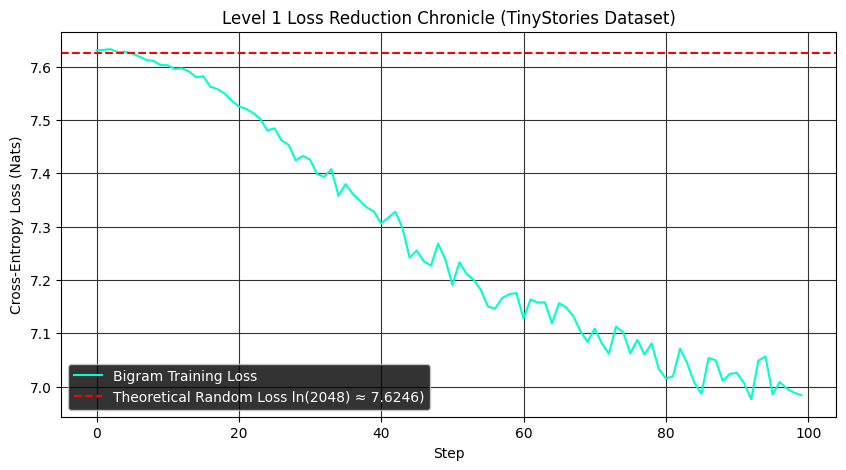

In [6]:
model = Level4_2_RoPE_Model()
configs = MODEL_CONFIGS

training_engine.train_and_save_model(model, configs, device, 100)
training_engine.plot_loss_history(configs)


In [7]:
training_engine.inspect_weight_file(configs["save_path"], False)

Loaded state_dict from ..\models\level4.2_rotary_positional_encoding.pt
Number of parameter tensors: 8
Number of parameters: 135,232

PARAMETER SUMMARY
embed: shape=(2048, 32), dtype=torch.float32, requires_grad=False, numel=65,536
unembed: shape=(32, 2048), dtype=torch.float32, requires_grad=False, numel=65,536
rms_norm_1.weight: shape=(32,), dtype=torch.float32, requires_grad=False, numel=32
rms_norm_2.weight: shape=(32,), dtype=torch.float32, requires_grad=False, numel=32
multi_attn.query_proj: shape=(32, 32), dtype=torch.float32, requires_grad=False, numel=1,024
multi_attn.key_proj: shape=(32, 32), dtype=torch.float32, requires_grad=False, numel=1,024
multi_attn.value_proj: shape=(32, 32), dtype=torch.float32, requires_grad=False, numel=1,024
multi_attn.out_proj: shape=(32, 32), dtype=torch.float32, requires_grad=False, numel=1,024
